# ReefSafe: complete reproducible analysis

**DOSM Datathon 2026 — Machine Learning and Artificial Intelligence for Sustainable Tourism**

This notebook rebuilds the processed dataset, runs the tested forward-looking model pipeline, audits data integrity, explains model performance, and explores the latest island screening priorities. The maintained logic lives in `scripts/`; this notebook is the professional, executable walkthrough.

> **Decision boundary:** ReefSafe schedules field verification. It does not calculate legal visitor caps, prove tourism causality, or estimate island-level revenue.

## 1. Data provenance

| Source | Evidence used | Treatment |
|---|---|---|
| Reef Check Malaysia annual reports | Island-year coral, substrate, fish, invertebrate and narrative indicators | Primary ecological evidence; extraction confidence retained |
| NOAA Coral Reef Watch | Sea-surface temperature anomaly and Degree Heating Weeks | Regional station match; missing values remain missing |
| OpenDOSM tourism and GDP series | National/state tourism context | Descriptive only; never downscaled to individual islands |
| DOSM Datathon 2026 booklet | Submission and evidence requirements | No fabricated or simulated observations |

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import polars as pl
try:
    from IPython.display import Image, display
except ImportError:  # Allows the notebook cells to run as a plain Python audit.
    def display(value):
        data = getattr(value, 'data', value)
        print(data.to_string(index=False) if hasattr(data, 'to_string') else data)
    class Image:
        def __init__(self, filename, width=None):
            self.filename, self.width = filename, width
        def __repr__(self):
            return f'Image({self.filename})'

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'processed'
OUTPUT = ROOT / 'output'

pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project root: {ROOT}')
print(f'Python: {sys.version.split()[0]}')

Project root: C:\Users\Chee\Documents\dosm2026
Python: 3.14.6


## 2. Rebuild the processed data and model outputs

The two commands below are the same tested entry points used to build the submission. Preprocessing parses NOAA DHW from its published column and removes generated tourism proxies. Modeling aligns each island record to its next observation and evaluates the latest five target years using earlier years only.

In [2]:
def run_module(module):
    result = subprocess.run(
        [sys.executable, '-m', module],
        cwd=ROOT,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    result.check_returncode()

run_module('scripts.run_preprocessing')
run_module('scripts.train_models')

STEP 1: INSPECT RAW STRUCTURED DATA BEFORE COMBINING

[1] Reef Check Survey Panel (model_ready): 404 rows, 40 columns
Columns: ['survey_year', 'island', 'state', 'ecoregion', 'n_sites', 'live_coral_cover_pct', 'lcc_prev', 'years_since_prev', 'lcc_change', 'lcc_change_rate'] ... (total 40 )
Null counts per column BEFORE merge:
  - survey_year                 :   0 nulls (Clean)
  - island                      :   0 nulls (Clean)
  - state                       :   0 nulls (Clean)
  - ecoregion                   :   2 nulls (0.5%)
  - n_sites                     :  66 nulls (16.3%)
  - live_coral_cover_pct        :   0 nulls (Clean)
  - lcc_prev                    :  56 nulls (13.9%)
  - years_since_prev            :  56 nulls (13.9%)
  - lcc_change                  :  56 nulls (13.9%)
  - lcc_change_rate             :  56 nulls (13.9%)
  - region_avg_lcc_pct          :   4 nulls (1.0%)
  - island_vs_region_pct        :   4 nulls (1.0%)
  - grp_other                   :  10 nulls (2.5%)


In [3]:
master = pl.read_csv(DATA / 'master_reef_tourism_dataset.csv')
metrics = pl.read_csv(DATA / 'model_evaluation_metrics.csv')
validation = pl.read_csv(DATA / 'model_validation_predictions.csv')
priorities = pl.read_csv(DATA / 'reef_priority_predictions.csv')
factor_relationships = pl.read_csv(DATA / 'factor_relationships.csv')
heat_summary = pl.read_csv(DATA / 'heat_category_summary.csv')

summary = pl.DataFrame({
    'Measure': ['Processed rows', 'Columns', 'Unique islands', 'Years', 'Forward-test rows', 'Latest priority rows'],
    'Value': [str(master.height), str(master.width), str(master['island'].n_unique()), f"{master['survey_year'].min()}–{master['survey_year'].max()}", str(validation.height), str(priorities.height)],
})
display(summary)

shape: (6, 2)
┌──────────────────────┬───────────┐
│ Measure              ┆ Value     │
│ ---                  ┆ ---       │
│ str                  ┆ str       │
╞══════════════════════╪═══════════╡
│ Processed rows       ┆ 404       │
│ Columns              ┆ 46        │
│ Unique islands       ┆ 56        │
│ Years                ┆ 2012–2025 │
│ Forward-test rows    ┆ 183       │
│ Latest priority rows ┆ 40        │
└──────────────────────┴───────────┘


## 3. Integrity checks

These checks fail loudly if fabricated proxy columns return, NOAA DHW is misread, future targets are aligned backward, or required outputs are empty.

In [4]:
forbidden = {'tourism_pressure_index', 'tourism_gdp_intensity_pct'}
assert forbidden.isdisjoint(master.columns), 'Generated tourism proxies found'
assert master.height == 404 and master.width == 46
assert master['island'].n_unique() == 56
assert master['noaa_max_dhw'].max() >= 4, 'NOAA DHW field may be parsed incorrectly'
assert (validation['target_year'] > validation['survey_year']).all(), 'Target must be later than feature year'
assert metrics.height > 0 and priorities.height > 0
print('PASS — processed data, chronology, NOAA DHW, and output checks')

PASS — processed data, chronology, NOAA DHW, and output checks


In [5]:
audit_columns = [
    'survey_year', 'island', 'state', 'live_coral_cover_pct',
    'lcc_change_rate', 'noaa_max_dhw', 'impact_anchor',
    'impact_trash', 'impact_bleaching', 'confidence',
]
audit = master.select(audit_columns)
display(audit.head(10))
display(audit.null_count().transpose(include_header=True, header_name='Column', column_names=['Missing values']))

shape: (10, 10)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ survey_ ┆ island  ┆ state   ┆ live_co ┆ lcc_cha ┆ noaa_ma ┆ impact_ ┆ impact_ ┆ impact_ ┆ confid │
│ year    ┆ ---     ┆ ---     ┆ ral_cov ┆ nge_rat ┆ x_dhw   ┆ anchor  ┆ trash   ┆ bleachi ┆ ence   │
│ ---     ┆ str     ┆ str     ┆ er_pct  ┆ e       ┆ ---     ┆ ---     ┆ ---     ┆ ng      ┆ ---    │
│ i64     ┆         ┆         ┆ ---     ┆ ---     ┆ f64     ┆ i64     ┆ i64     ┆ ---     ┆ str    │
│         ┆         ┆         ┆ f64     ┆ f64     ┆         ┆         ┆         ┆ i64     ┆        │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ 2012    ┆ Tioman  ┆ Pahang  ┆ 55.81   ┆ null    ┆ 0.15    ┆ 1       ┆ 1       ┆ 0       ┆ PDF    │
│         ┆         ┆         ┆         ┆         ┆         ┆         ┆         ┆         ┆ geomet │
│         ┆         ┆         ┆         ┆         ┆         ┆         ┆    

## 4. Forward-test model comparison

MAE and RMSE are in coral-cover percentage points per year; lower is better. R² compares the model with a constant mean prediction; higher is better. Model selection uses MAE, but the baseline and R² remain visible to prevent overclaiming.

In [6]:
baseline = metrics.filter(pl.col('Model') == 'Baseline mean').row(0, named=True)
challengers = metrics.filter(pl.col('Model') != 'Baseline mean')
best = challengers.sort('MAE (%/yr)').row(0, named=True)
improvement = 1 - best['MAE (%/yr)'] / baseline['MAE (%/yr)']

display(metrics)
print(f"Selected: {best['Model']}")
print(f"MAE improvement over baseline: {improvement:.1%}")
print(f"Forward-test R²: {best['R2 Score']:.3f}")
print('Interpretation: screening-only; field verification remains mandatory.')

shape: (4, 4)
┌───────────────────┬────────────┬─────────────┬──────────┐
│ Model             ┆ MAE (%/yr) ┆ RMSE (%/yr) ┆ R2 Score │
│ ---               ┆ ---        ┆ ---         ┆ ---      │
│ str               ┆ f64        ┆ f64         ┆ f64      │
╞═══════════════════╪════════════╪═════════════╪══════════╡
│ Baseline mean     ┆ 5.991      ┆ 8.1         ┆ -0.019   │
│ Ridge regression  ┆ 5.993      ┆ 7.909       ┆ 0.029    │
│ Gradient boosting ┆ 5.902      ┆ 7.817       ┆ 0.051    │
│ Random forest     ┆ 6.123      ┆ 8.073       ┆ -0.012   │
└───────────────────┴────────────┴─────────────┴──────────┘
Selected: Gradient boosting
MAE improvement over baseline: 1.5%
Forward-test R²: 0.051
Interpretation: screening-only; field verification remains mandatory.


notebook-cell-7:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


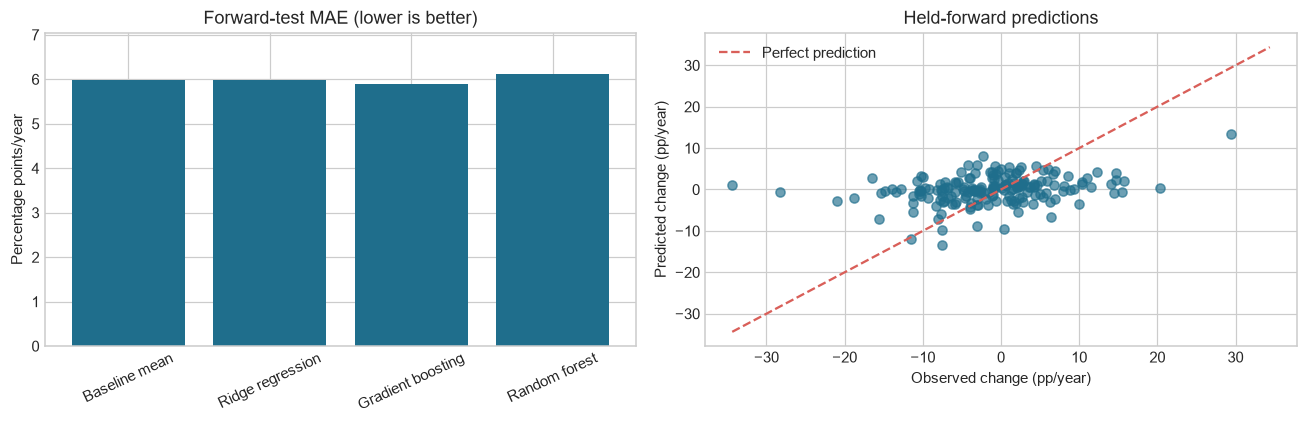

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(metrics['Model'].to_list(), metrics['MAE (%/yr)'].to_list(), color='#1F6E8C')
axes[0].set_title('Forward-test MAE (lower is better)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Percentage points/year')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylim(0, max(metrics['MAE (%/yr)']) * 1.15)

axes[1].scatter(validation['target_lcc_change_rate'].to_numpy(), validation['predicted_change'].to_numpy(), alpha=.65, color='#1F6E8C')
limit = max(validation['target_lcc_change_rate'].abs().max(), validation['predicted_change'].abs().max())
axes[1].plot([-limit, limit], [-limit, limit], '--', color='#D95F59', label='Perfect prediction')
axes[1].set_title('Held-forward predictions')
axes[1].set_xlabel('Observed change (pp/year)')
axes[1].set_ylabel('Predicted change (pp/year)')
axes[1].legend()
plt.tight_layout()
plt.show()

### Why the submitted model does not use XGBoost

The dataset has only 348 next-observation transitions and the selected scikit-learn Gradient Boosting model already tests the tree-boosting hypothesis. Its gain over the mean baseline is only about 1.5%, so adding a more complex library would not solve the main constraint: sparse, irregular island histories. XGBoost is a valid future challenger, but it should use the identical expanding-year evaluation and replace the current model only if improvement is meaningful and stable across test years.

## 5. Factor relationships

These diagnostics relate factors measured at the current island observation to the **next observed** annualized coral-cover change. Continuous variables use Spearman rank correlation, which can detect monotonic non-linear relationships. Binary narrative flags compare the mean next change when a stressor was mentioned versus not mentioned. The calculations are descriptive and are not used as proof of causation or as a feature-selection gate.

In [8]:
display(factor_relationships)
display(heat_summary)
display(Image(filename=str(OUTPUT / 'fig4_factor_relationships.png'), width=900))

shape: (9, 7)
┌─────────────────┬─────────────────┬─────┬───────────┬────────────────┬──────────┬────────────────┐
│ factor          ┆ analysis        ┆ n   ┆ statistic ┆ statistic_unit ┆ p_value  ┆ caution        │
│ ---             ┆ ---             ┆ --- ┆ ---       ┆ ---            ┆ ---      ┆ ---            │
│ str             ┆ str             ┆ i64 ┆ f64       ┆ str            ┆ f64      ┆ str            │
╞═════════════════╪═════════════════╪═════╪═══════════╪════════════════╪══════════╪════════════════╡
│ noaa_max_dhw    ┆ Spearman rank   ┆ 348 ┆ -0.104578 ┆ rho            ┆ 0.051271 ┆ Descriptive    │
│                 ┆ correlation     ┆     ┆           ┆                ┆          ┆ lagged         │
│                 ┆                 ┆     ┆           ┆                ┆          ┆ association;   │
│                 ┆                 ┆     ┆           ┆                ┆          ┆ not a causal   │
│                 ┆                 ┆     ┆           ┆                ┆     

### How to interpret the factor diagnostics

- A positive or negative statistic describes the sample; it does not identify a cause.
- A weak overall correlation does not rule out a threshold effect such as DHW ≥ 4.
- A small p-value does not remove confounding by island, year, survey coverage or unmeasured local conditions.
- Narrative-flag absence can mean ‘not reported’, so group differences must be treated cautiously.
- Forward-test model performance remains the criterion for predictive usefulness.

## 6. Priority explorer

The final model scores the latest available record for each island. The top quartile is labelled **High screening priority**. Evidence and action text come from observed thermal, anchor, and waste/pollution indicators—not from the model alone.

In [9]:
priority_columns = [
    'priority_rank', 'island', 'state', 'live_coral_cover_pct',
    'predicted_next_change_pct_per_year', 'prediction_lower', 'prediction_upper',
    'priority_tier', 'evidence', 'recommended_next_step', 'confidence',
]
display(priorities.select(priority_columns).head(10))

shape: (10, 11)
┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ priori ┆ island ┆ state  ┆ live_c ┆ predic ┆ predic ┆ predic ┆ priori ┆ eviden ┆ recomm ┆ confid │
│ ty_ran ┆ ---    ┆ ---    ┆ oral_c ┆ ted_ne ┆ tion_l ┆ tion_u ┆ ty_tie ┆ ce     ┆ ended_ ┆ ence   │
│ k      ┆ str    ┆ str    ┆ over_p ┆ xt_cha ┆ ower   ┆ pper   ┆ r      ┆ ---    ┆ next_s ┆ ---    │
│ ---    ┆        ┆        ┆ ct     ┆ nge_pc ┆ ---    ┆ ---    ┆ ---    ┆ str    ┆ tep    ┆ str    │
│ i64    ┆        ┆        ┆ ---    ┆ t_per_ ┆ f64    ┆ f64    ┆ str    ┆        ┆ ---    ┆        │
│        ┆        ┆        ┆ f64    ┆ year   ┆        ┆        ┆        ┆        ┆ str    ┆        │
│        ┆        ┆        ┆        ┆ ---    ┆        ┆        ┆        ┆        ┆        ┆        │
│        ┆        ┆        ┆        ┆ f64    ┆        ┆        ┆        ┆        ┆        ┆        │
╞════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪══

notebook-cell-10:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


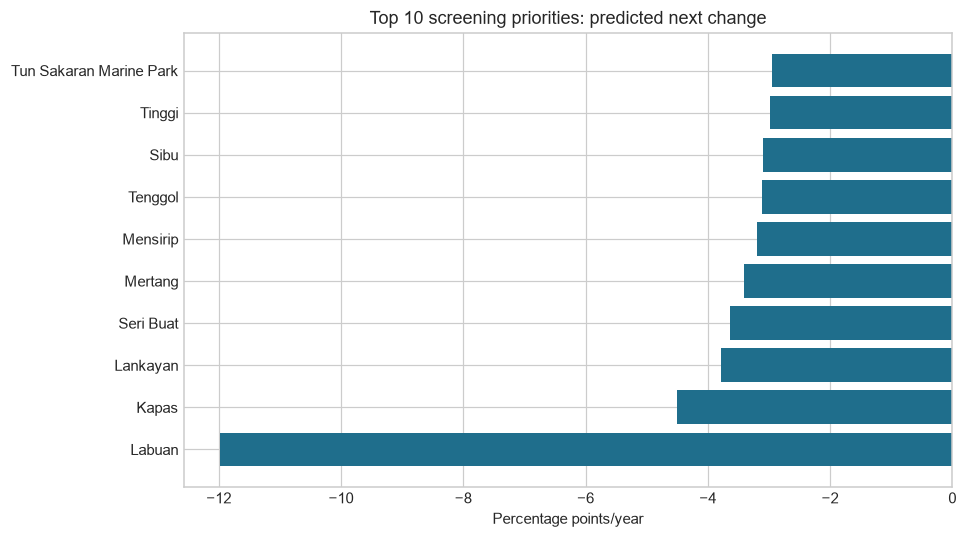

In [10]:
top = priorities.head(10).sort('predicted_next_change_pct_per_year')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top['island'].to_list(), top['predicted_next_change_pct_per_year'].to_list(), color='#1F6E8C')
ax.set_title('Top 10 screening priorities: predicted next change')
ax.set_xlabel('Percentage points/year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [11]:
def inspect_island(name):
    match = priorities.filter(pl.col('island').str.to_lowercase() == name.casefold()).select(priority_columns)
    if match.height == 0:
        available = ', '.join(sorted(priorities['island'].unique().to_list()))
        raise ValueError(f"Unknown island: {name}. Available: {available}")
    return match.transpose(include_header=True, header_name='Measure', column_names=[name])

display(inspect_island('Labuan'))  # Change the name to explore another island.

shape: (11, 2)
┌────────────────────────────────────┬─────────────────────────────────────────────────────────────┐
│ Measure                            ┆ Labuan                                                      │
│ ---                                ┆ ---                                                         │
│ str                                ┆ str                                                         │
╞════════════════════════════════════╪═════════════════════════════════════════════════════════════╡
│ priority_rank                      ┆ 1                                                           │
│ island                             ┆ Labuan                                                      │
│ state                              ┆ Sabah                                                       │
│ live_coral_cover_pct               ┆ 24.23                                                       │
│ predicted_next_change_pct_per_year ┆ -11.973949241216234                  

## 7. Project assumptions

| Assumption | Why it is needed | Mitigation |
|---|---|---|
| Island names represent comparable monitoring units over time | Site boundaries can change | Retain source confidence and verify large changes |
| Live coral cover is sufficiently comparable across reports | Methods and surveyed sites may vary | Use results only for screening |
| Change is approximately linear between irregular surveys | Intermediate disturbance and recovery are unobserved | Report annualized change, never invented annual observations |
| A NOAA regional station represents broad island heat exposure | Local reef temperatures can differ | Request in-water confirmation |
| Current conditions can help screen the next observation | Later unmeasured events may dominate | Use lagged association language |
| Narrative mention indicates presence, while no mention is uncertain | Reporting intensity varies | Avoid treating zero as confirmed absence |
| Fold-specific median imputation is adequate | Missingness may be systematic | Keep raw missingness and impute inside each fold |
| Earlier patterns have limited relevance to later years | Ecological regimes may shift | Use expanding-year evaluation |
| The top quartile is a manageable workload queue | It is not a scientific threshold | Require field verification |

The complete, maintained register is in `docs/assumptions.md`. OpenDOSM tourism and GDP totals are deliberately **not** assumed to represent individual-island pressure.

## 8. Decision guardrails

1. **High priority means inspect first**, not close the island.
2. **Read the prediction band and source confidence**, not only the rank.
3. **DHW ≥ 4** triggers coordinated bleaching assessment; do not attribute heat-driven loss to visitors.
4. **Anchor evidence** triggers mooring and anchoring checks.
5. **Waste/pollution evidence** triggers waste and wastewater checks.
6. **No dominant observed stressor** means validate in the field before restrictions.

The highest-value next enhancement is better island-level operational data—daily visitors, boat trips, mooring use, wastewater discharge, closures, and consistent site identifiers—not a more complicated algorithm.

## 9. Submission figures and automated tests

The saved figures below are generated by the model script and used in the report. The final cell runs the repository's automated integrity tests.

In [12]:
for filename in ['fig1_model_performance_cv.png', 'fig2_actual_vs_predicted.png', 'fig3_feature_importance.png', 'fig4_factor_relationships.png']:
    display(Image(filename=str(OUTPUT / filename), width=760))

Image(C:\Users\Chee\Documents\dosm2026\output\fig1_model_performance_cv.png)
Image(C:\Users\Chee\Documents\dosm2026\output\fig2_actual_vs_predicted.png)
Image(C:\Users\Chee\Documents\dosm2026\output\fig3_feature_importance.png)
Image(C:\Users\Chee\Documents\dosm2026\output\fig4_factor_relationships.png)


In [13]:
result = subprocess.run(
    [sys.executable, '-m', 'unittest', '-v'],
    cwd=ROOT, capture_output=True, text=True,
)
print(result.stdout)
print(result.stderr)
result.check_returncode()
print('Notebook complete — pipeline outputs and automated checks passed.')


test_factor_plot_renders_with_supported_matplotlib_api (tests.test_factor_diagnostics.FactorDiagnosticTests.test_factor_plot_renders_with_supported_matplotlib_api) ... ok
test_notebook_is_complete_and_uses_tested_pipeline (tests.test_notebook.NotebookTests.test_notebook_is_complete_and_uses_tested_pipeline) ... ok
test_forward_splits_never_train_on_test_or_future_years (tests.test_pipeline.PipelineTests.test_forward_splits_never_train_on_test_or_future_years) ... ok
test_heat_category_uses_declared_dhw_thresholds (tests.test_pipeline.PipelineTests.test_heat_category_uses_declared_dhw_thresholds) ... ok
test_next_observation_target_is_from_a_later_year (tests.test_pipeline.PipelineTests.test_next_observation_target_is_from_a_later_year) ... ok
test_noaa_parser_reads_dhw_column (tests.test_pipeline.PipelineTests.test_noaa_parser_reads_dhw_column) ... ok
test_processed_data_has_no_generated_tourism_proxies (tests.test_pipeline.PipelineTests.test_processed_data_has_no_generated_tourism_pr